In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
sys.path.append('../folps')
import folps as FOLPS
!pwd

✅ Using NumPy with CPU.
/Users/henoriega/Desktop/FOLSPpipe_final/FOLPSpipe-folpsD-jax-desilike/_tests


# Comparison to Mathematica Outputs

Mathematica outputs are obtained from file M_Sugiyama_basis.nb

Calculating matrices (no save path specified)
[FOLPS] Model Pk: EFT, damping: None (WARNING: EFT does not use damping, ignoring damping)


Text(0.5, 1.0, 'B_l1l2L * H_l1l2L')

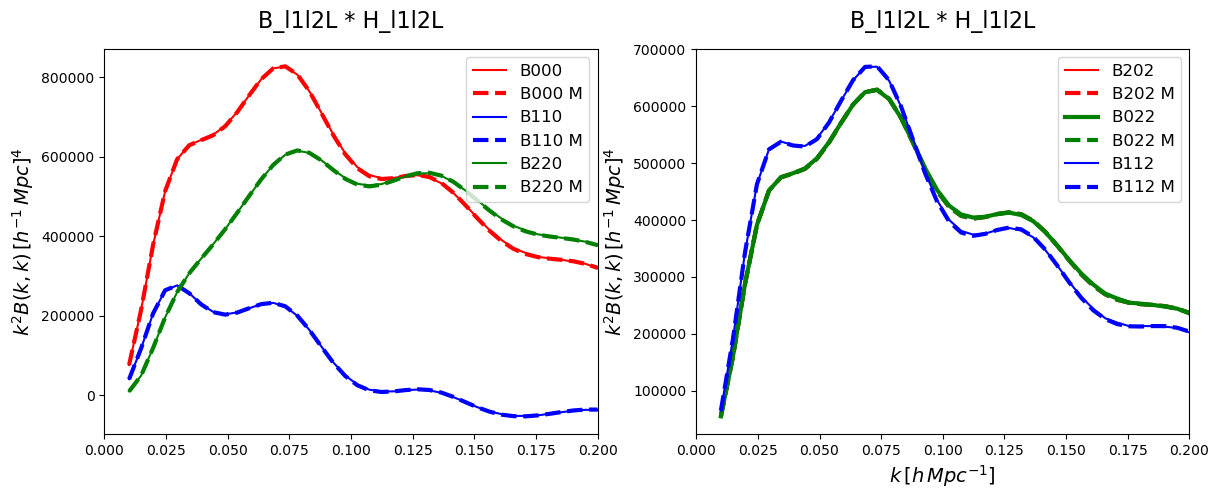

In [2]:
#Test with Mathematica

inputpkT = np.loadtxt('pk_linear_simtocmass.txt', unpack = True)
qpar,qperp=1,1

#omega_i = Omega_i h² 
omega_b = 0.02242;        #baryons
omega_cdm = 0.117;       #CDM
omega_ncdm = 0.0;    #massive neutrinos 
h = 0.67;                 #h = H0/100
z_pk = 0.57;                 #evaluation redshift
CosmoParams = [z_pk, omega_b, omega_cdm, omega_ncdm, h]


Omega_m = (omega_cdm+omega_b+omega_ncdm)/h**2
fnu = omega_ncdm/(omega_cdm+omega_b+omega_ncdm)
# CosmoParams = [z_pk, omega_b, omega_cdm, omega_ncdm, h]  //Deprecated. Now folps uses kwargs

kwargs = {'z': z_pk,
          'h': h,
          'Omega_m': Omega_m,
          # 'f0': np.float64(0.6880638641959066),  #if not provided, the code computes it
          'fnu': fnu,
         }


#bias parameters
b1 = 1.0;                 
b2= 8/21*(b1-1)
bs2= -4/7*(b1-1)      
b3nl = 32/315*(b1 - 1);  

#EFT parameters
alpha0, alpha2, alpha4 = 0,0,0    # PEFT(k) = (alpha0 + alpha2*mu^2+ alpha4*mu^4)  k^2 Plin(k)
ctilde = 0               #NLO counterterm
X_FoG = 0  # uses a Lorentzian Damping 1/(1+x^2), with x = X_FoG f sigma_v mu. 

#Stochatics parameters
# Noise is Pshot = PshotP * ( alphashot0 + alphashot2*(k*mu)**2 )
alphashot0 = 0;          
alphashot2 = 0;            
PshotP = 0    # =1/barn.  Poissonian shot noise
NuisanParams = [b1, b2, bs2, b3nl, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP,X_FoG]


matrix = FOLPS.MatrixCalculator(A_full=False) 
mmatrices = matrix.get_mmatrices()

# Compute 1loop integrals
k_ev = np.logspace(np.log10(0.01), np.log10(0.3), num = 100) # array of k_ev in [h/Mpc]

nonlinear = FOLPS.NonLinearPowerSpectrumCalculator(mmatrices=mmatrices,kernels='fk',**kwargs)
table, table_nonwiggles = nonlinear.calculate_loop_table(k=inputpkT[0], pklin=inputpkT[1],cosmo=None, **kwargs)
multipoles = FOLPS.RSDMultipolesPowerSpectrumCalculator() 
pkl0, pkl2, pkl4  = multipoles.get_rsd_pkell(kobs=k_ev, qpar=qpar, qper=qperp, pars=NuisanParams,
                                       table=table, table_now=table_nonwiggles,
                                       bias_scheme='folps', damping='lor'
                                       )
kh=k_ev

# nonlinear = FOLPS.NonLinear(inputpkT, CosmoParams)
# kh, pkl0, pkl2, pkl4 = FOLPS.RSDmultipoles(k_ev, NuisanParams, qpar,qperp)


Pshot = 0; # This would be the same as PshopP*alphashot0 if the bispectrum were computed up to 1loop (I think!)
Bshot = 0;
c1,c2=0,0
X_FoG_bk=0

bisp_nuis_params = [b1, b2, bs2, c1,c2,Pshot,Bshot, X_FoG_bk]
OmM=(omega_cdm+omega_b+omega_ncdm)/h**2
bisp_cosmo_params = [z_pk,OmM,h]
FOLPS.get_f0(z_pk,OmM),OmM

k_ev = np.linspace(0.01,0.2, num = 40) 
k_ev_bk=np.vstack([k_ev,k_ev]).T   # List of pairs of k. (B=B(k1,k2))
precision=[10,10,10]

k1k2pairs=k_ev_bk

f0=FOLPS.get_f0(z_pk,OmM)

k_pkl_pklnw=np.array([table[0], table[1], table[1]]) #Without IR

bispectrum = FOLPS.BispectrumCalculator()
Bk = bispectrum.Sugiyama_Bell(
                                      f=f0,  
                                      bpars=bisp_nuis_params,
                                      k_pkl_pklnw=k_pkl_pklnw, 
                                      k1k2pairs=k1k2pairs,
                                      qpar=qpar, 
                                      qper=qperp,
                                      precision=[8,10,10], 
                                      damping=None,
                                      multipoles = ['B000', 'B110', 'B220', 'B202', 'B022', 'B112'],
                                      renormalize = True,
                                      interpolation_method='linear',
                                      #bias_scheme='folps'
)



B000, B110, B220, B202,B022, B112 = Bk

k_m, B000_m, B110_m, B220_m, B202_m, B022_m, B112_m = np.loadtxt('M_Bl1l2L_mathematica.txt', unpack=True)


fig, axs = plt.subplots(1, 2, figsize=(14, 5))
xmax=0.2
axs[0].set_ylabel(r'$k^2 B(k,k) \, [h^{-1} \,  Mpc]^4$', fontsize=14)
axs[0].plot(k_ev, k_ev**2 * B000, label=r'B000', ls='-', color='red')
axs[0].plot(k_ev, k_ev**2 * B000_m, label=r'B000 M', ls='--', color='red',lw=3)
axs[0].plot(k_ev, k_ev**2 * B110, label=r'B110', ls='-', color='blue')
axs[0].plot(k_ev, k_ev**2 * B110_m, label=r'B110 M', ls='--', color='blue',lw=3)
axs[0].plot(k_ev, k_ev**2 * B220, label=r'B220', ls='-', color='green')
axs[0].plot(k_ev, k_ev**2 * B220_m, label=r'B220 M', ls='--', color='green',lw=3)
axs[0].set_xlim([0, xmax])
axs[0].legend(fontsize=12, loc='best')
axs[0].set_title('B_l1l2L * H_l1l2L', fontsize=16, pad=15)

axs[1].set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize=14)
axs[1].set_ylabel(r'$k^2 B(k,k) \, [h^{-1} \,  Mpc]^4$', fontsize=14)
axs[1].plot(k_ev, k_ev**2 * B202, label=r'B202', ls='-', color='red')
axs[1].plot(k_ev, k_ev**2 * B202_m, label=r'B202 M', ls='--', color='red',lw=3)
axs[1].plot(k_ev, k_ev**2 * B022, label=r'B022  ', ls='-', color='green',lw=3)
axs[1].plot(k_ev, k_ev**2 * B022_m, label=r'B022 M', ls='--', color='green',lw=3)
axs[1].plot(k_ev, k_ev**2 * B112, label=r"B112", ls='-', color='blue')
axs[1].plot(k_ev, k_ev**2 * B112_m, label=r'B112 M', ls='--', color='blue',lw=3)
axs[1].set_xlim([0, xmax])
axs[1].legend(fontsize=12, loc='best')
axs[1].set_title('B_l1l2L * H_l1l2L', fontsize=16, pad=15)